В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням kNearestNeighboors, знайдемо оптимальні гіперпараметри для цього методу і зробимо базові ансамблі. Це дасть змогу порівняти перформанс моделі з попередніми вивченими методами.

0. Зчитайте дані `train.csv` та зробіть препроцесинг використовуючи написаний Вами скрипт `process_bank_churn.py` так, аби в результаті отримати дані в розбитті X_train, train_targets, X_val, val_targets для експериментів.

  Якщо Вам не вдалось реалізувати в завданні `2.3. Дерева прийняття рішень` скрипт `process_bank_churn.py` - можна скористатись готовим скриптом з запропонованого рішення того завдання.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

from process_bank_churn import preprocess_data, preprocess_new_data

In [3]:
train_raw_df = pd.read_csv('/content/drive/MyDrive/ML DS/Module 2/Bank Customer Churn Prediction/train.csv', index_col=0)

In [4]:
train_raw_df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
id,,,,,,,,,,,,,
0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [5]:
X_train, y_train, X_val, y_val, input_cols, scaler, encoder = preprocess_data(train_raw_df)

1. Навчіть на цих даних класифікатор kNN з параметрами за замовченням і виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах. Зробіть заключення про отриману модель: вона хороша/погана, чи є high bias/high variance?

In [37]:
import numpy as np
import matplotlib.pyplot as plt

from mlxtend.plotting import plot_decision_regions

from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve, auc, roc_auc_score, RocCurveDisplay

In [14]:
import matplotlib
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [8]:
knn = KNeighborsClassifier()

In [9]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [11]:
def compute_auroc_and_build_roc(model, inputs, targets, name=''):
  # Predict probabilities
  y_pred_proba = model.predict_proba(inputs)[:, 1]

  # Compute ROC curve
  fpr, tpr, thresholds = roc_curve(targets, y_pred_proba)

    # Compute AUROC
  roc_auc = auc(fpr, tpr)
  print(f'AUROC for {name}: {roc_auc:.2f}')

  # Plot the ROC curve
  plt.figure()
  plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) Curve for {name}')
  plt.legend(loc="lower right")
  plt.show()

AUROC for Training: 0.96


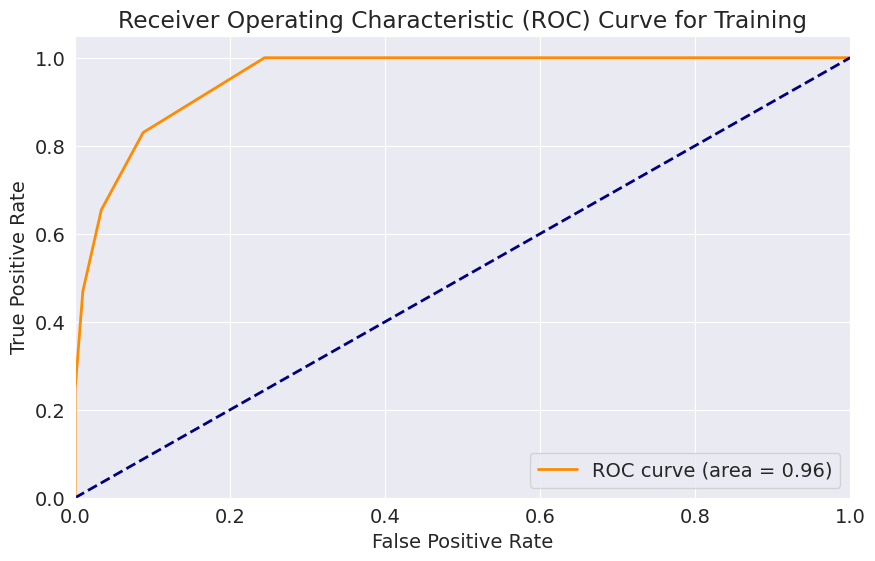

AUROC for Validation: 0.85


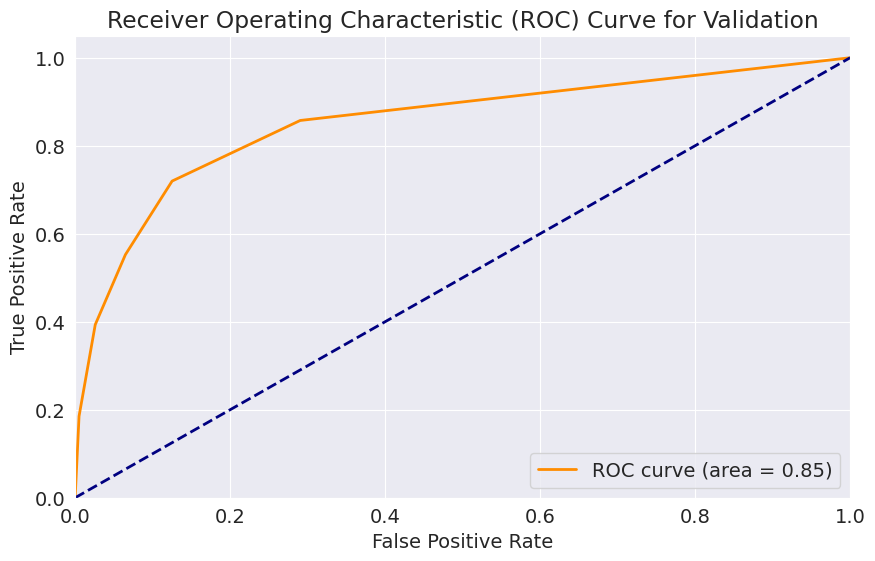

In [15]:
compute_auroc_and_build_roc(knn, X_train, y_train, 'Training')
compute_auroc_and_build_roc(knn, X_val, y_val, 'Validation')

Отримали досить високий показник для тренувальних даних, проте значно нижчий для валідаційних. Отже, можна зробити висновок про наявність High variance (overfitting) - модель ненадійна, і потрібно підкоригувати гіперпараметри для покращення якості моделі

2. Використовуючи `GridSearchCV` знайдіть оптимальне значення параметра `n_neighbors` для класифікатора `kNN`. Псотавте крос валідацію на 5 фолдів.

  Після успішного завершення пошуку оптимального гіперпараметра
    - виведіть найкраще значення параметра
    - збережіть в окрему змінну `knn_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `knn_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пукнтом (2) цього завдання? Чи є вона краще за дерево прийняття рішень з попереднього ДЗ?

In [16]:
params_knn = {'n_neighbors': np.arange(1, 25)}
knn_gs = GridSearchCV(knn, params_knn, cv=5)

In [17]:
knn_gs.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])})

Отримали оптимальну кількість K = 9

In [18]:
knn_gs.best_estimator_

KNeighborsClassifier(n_neighbors=np.int64(9))

In [19]:
knn_best = knn_gs.best_estimator_

AUROC for Training: 0.94


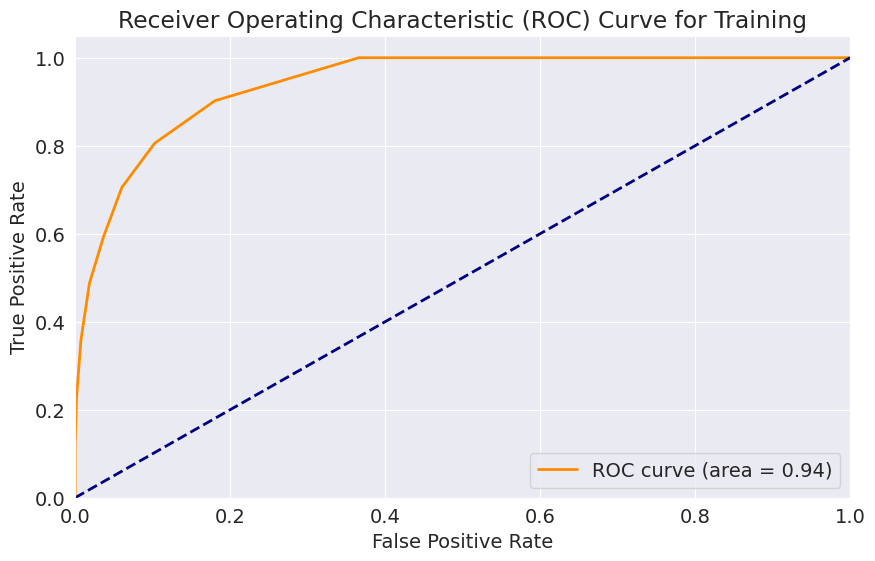

AUROC for Validation: 0.88


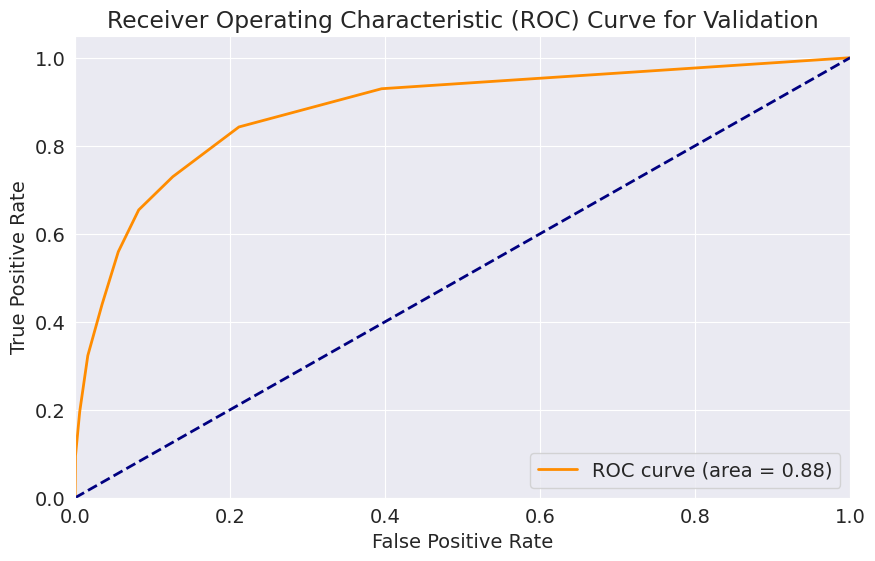

In [20]:
compute_auroc_and_build_roc(knn_best, X_train, y_train, 'Training')
compute_auroc_and_build_roc(knn_best, X_val, y_val, 'Validation')

Отримана модель показала кращий результат на валідаційних даних, ніж у попередній моделі зі кількістю К=5 за замовчуванням. Показник для тестових даних знизився. Все ще різниця між показником для тестових та валідаційних даних вказує на оверфіт.

Для дерева прийняття рішень, показники на тестовій та валідаційній вибірках були відповідно 0,93 та 0,92. Отже, з деревом прийняття рішень модель працювала краще

3. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `GridSearchCV` за сіткою параметрів
  - `max_depth` від 1 до 20 з кроком 2
  - `max_leaf_nodes` від 2 до 10 з кроком 1

  Обовʼязково при цьому ініціюйте модель з фіксацією `random_state`.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `dt_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли вручну?

In [30]:
dt = DecisionTreeClassifier(random_state=42)

In [31]:
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [32]:
params_dt = {'max_depth': np.arange(1, 21,2),
            'max_leaf_nodes': np.arange(2,11)}
dt_gs = GridSearchCV(dt, params_dt, cv=3, scoring="roc_auc")

In [33]:
%%time
dt_gs.fit(X_train, y_train)

CPU times: user 5.16 s, sys: 8.19 ms, total: 5.17 s
Wall time: 5.18 s


GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19]),
                         'max_leaf_nodes': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10])},
             scoring='roc_auc')

Отримані оптимальні гіперпараметри:

In [34]:
dt_gs.best_estimator_

DecisionTreeClassifier(max_depth=np.int64(5), max_leaf_nodes=np.int64(10),
                       random_state=42)

In [35]:
dt_best=dt_gs.best_estimator_

AUROC for Training: 0.90


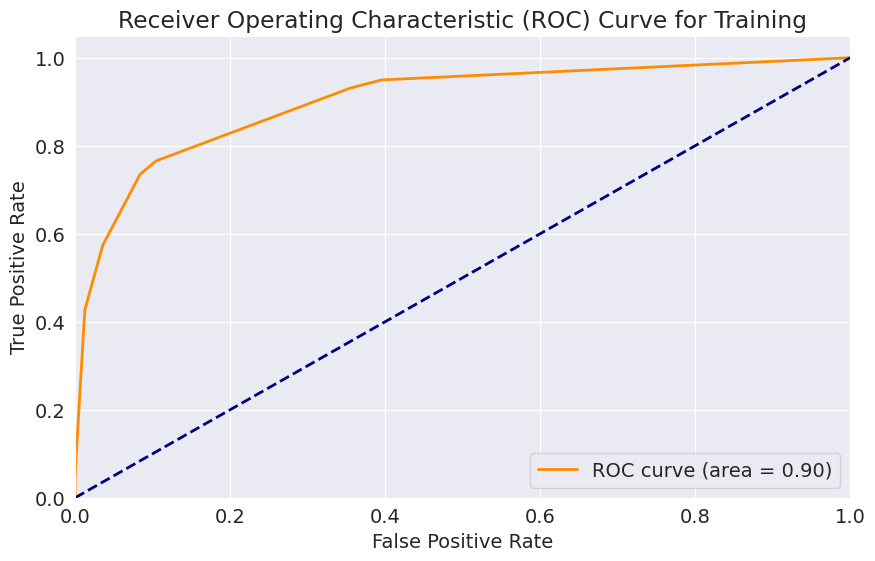

AUROC for Validation: 0.90


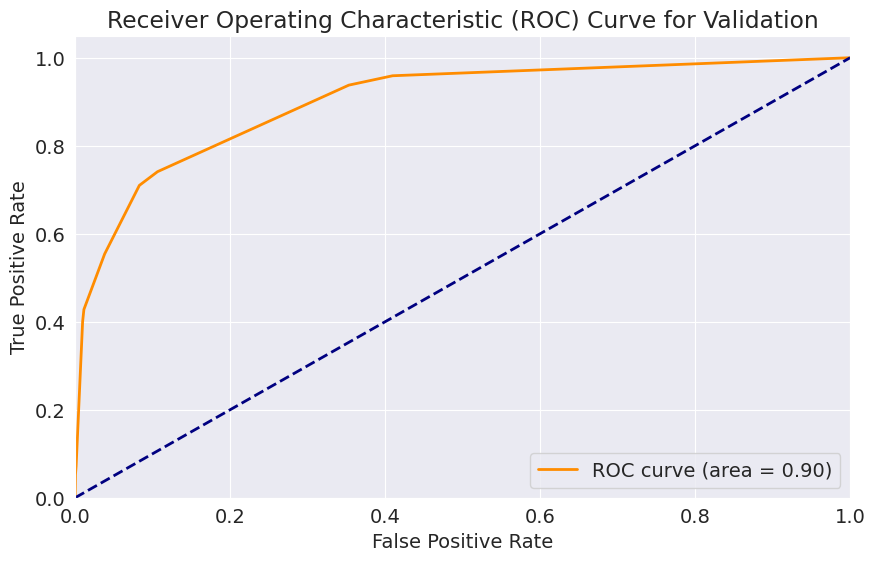

In [36]:
compute_auroc_and_build_roc(dt_best, X_train, y_train, 'Training')
compute_auroc_and_build_roc(dt_best, X_val, y_val, 'Validation')

Отримані показники якості для тренувальної та валідаційної вибірок однакові (0,9), проте нижчі, ніж для моделі дерева з показниками, знайденими вручну (показники на тестовій та валідаційній вибірках були відповідно 0,93 та 0,92)

4. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `RandomizedSearchCV` за заданою сіткою параметрів і кількість ітерацій 40.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, зафіксуйте `random_seed` процедури крос валідації та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_random_search_best` найкращу модель, знайдену з `RandomizedSearchCV`
    - оцініть якість передбачень  `dt_random_search_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли з `GridSearch`?
    - проаналізуйте параметри `dt_random_search_best` і порівняйте з параметрами `dt_best` - яку бачите відмінність? Ця вправа потрібна аби зрозуміти, як різні налаштування `DecisionTreeClassifier` впливають на якість моделі.

In [41]:
params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 20),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

In [38]:
?RandomizedSearchCV

In [42]:
dt_rand = RandomizedSearchCV(
    dt,
    params_dt,
    n_iter = 40,
    cv=3,
    scoring='roc_auc',
    verbose=3,
    refit=True,
    random_state=42
)

In [46]:
%%timedt_rand.fit(X_train, y_train)

Fitting 3 folds for each of 40 candidates, totalling 120 fits
[CV 1/3] END criterion=gini, max_depth=10, max_features=None, max_leaf_nodes=9, min_samples_leaf=4, min_samples_split=5, splitter=random;, score=0.857 total time=   0.0s
[CV 2/3] END criterion=gini, max_depth=10, max_features=None, max_leaf_nodes=9, min_samples_leaf=4, min_samples_split=5, splitter=random;, score=0.865 total time=   0.0s
[CV 3/3] END criterion=gini, max_depth=10, max_features=None, max_leaf_nodes=9, min_samples_leaf=4, min_samples_split=5, splitter=random;, score=0.872 total time=   0.0s
[CV 1/3] END criterion=gini, max_depth=1, max_features=sqrt, max_leaf_nodes=10, min_samples_leaf=8, min_samples_split=10, splitter=best;, score=0.621 total time=   0.0s
[CV 2/3] END criterion=gini, max_depth=1, max_features=sqrt, max_leaf_nodes=10, min_samples_leaf=8, min_samples_split=10, splitter=best;, score=0.621 total time=   0.0s
[CV 3/3] END criterion=gini, max_depth=1, max_features=sqrt, max_leaf_nodes=10, min_sample

RandomizedSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
                   n_iter=40,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19]),
                                        'max_features': [None, 'sqrt', 'log2'],
                                        'max_leaf_nodes': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19]),
                                        'min_samples_leaf': [1, 2, 4, 8],
                                        'min_samples_split': [2, 5, 10, 20],
                                        'splitter': ['best', 'random']},
                   random_state=42, scoring='roc_auc', verbose=3)


```
CPU times: user 1.61 s, sys: 2.72 ms, total: 1.61 s  
Wall time: 1.62 s
```



In [44]:
dt_random_search_best=dt_rand.best_estimator_

In [45]:
dt_random_search_best

DecisionTreeClassifier(criterion='entropy', max_depth=np.int64(16),
                       max_leaf_nodes=np.int64(14), min_samples_leaf=2,
                       min_samples_split=20, random_state=42)

AUROC for Training: 0.92


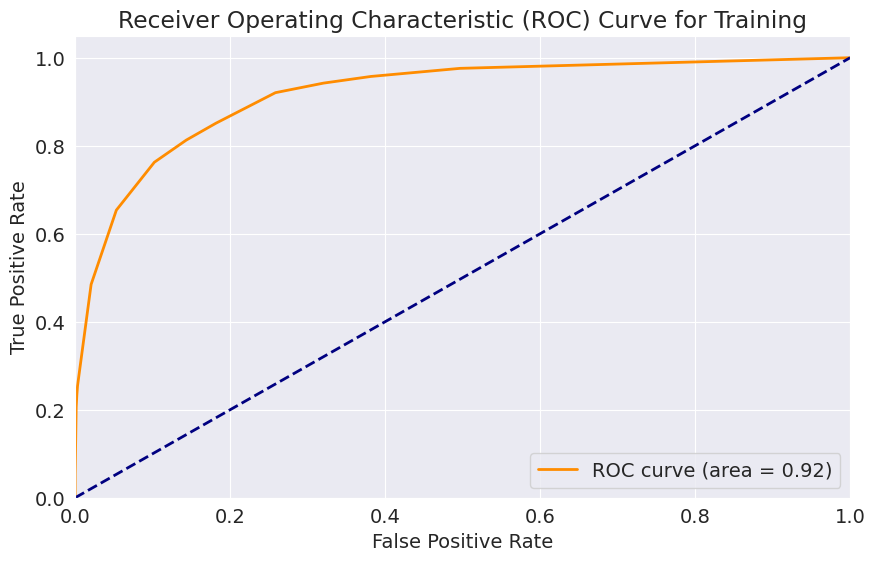

AUROC for Validation: 0.92


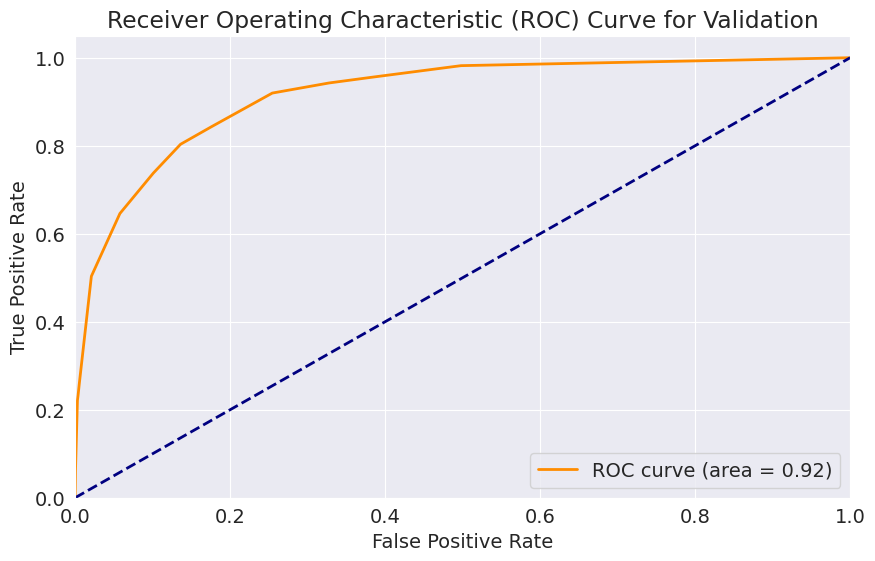

In [48]:
compute_auroc_and_build_roc(dt_random_search_best, X_train, y_train, 'Training')
compute_auroc_and_build_roc(dt_random_search_best, X_val, y_val, 'Validation')

Для тренувальної та валідаційної вибірки отримали auroc = 0,92.  
Цей результат є кращим, ніж у моделі з параметрами, знайденими через GridSearchCV.  

Параметри найкращої моделі з RandomSearch `dt_random_search_best`:
- criterion='entropy'
- max_depth=16,
- max_leaf_nodes=14,
- min_samples_leaf=2,
- min_samples_split=20

Для моделі з GridSearch `dt_best`:
- max_depth=5,
- max_leaf_nodes=10

Бачимо, що для кращої моделі (з гіперпараметрами з RandomSearchCV) глибина дерева більша (16 проти 5), кількість листків також більша (14 проти 10). Отже, комбінація з гіперпараметрами, знайденими з RandomSearchCV дала більш якісну модель за рахунок більшої глибини дерева та більшої кількості leaf nodes з уникненням перенавчання


5. Якщо у Вас вийшла метрика `AUROC` в цій серії експериментів - зробіть ще один `submission` на Kaggle і додайте код для цього і скріншот скора на публічному лідерборді нижче.

  Сподіваюсь на цьому етапі ви вже відчули себе справжнім дослідником 😉

In [50]:
test_raw_df = pd.read_csv('/content/drive/MyDrive/ML DS/Module 2/Bank Customer Churn Prediction/test.csv')

In [51]:
test_raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97


In [52]:
test_data = preprocess_new_data(test_raw_df, input_cols, scaler, encoder)

In [53]:
test_data['Exited'] = dt_random_search_best.predict_proba(test_data)[:, 1]

In [54]:
test_data.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male,Exited
0,0.365155,0.214286,0.2,0.696265,0.000000,1.0,1.0,0.789477,1.0,0.0,1.0,0.237911
1,0.286396,0.375000,0.5,0.000000,0.333333,1.0,1.0,0.337131,0.0,0.0,1.0,0.012115
2,0.656325,0.446429,0.8,0.000000,0.333333,1.0,0.0,0.783859,0.0,0.0,1.0,0.203947
3,0.682578,0.482143,0.3,0.000000,0.000000,1.0,1.0,0.834571,0.0,1.0,1.0,0.569848
4,0.384248,0.446429,0.8,0.000000,0.333333,1.0,1.0,0.718421,0.0,1.0,1.0,0.082171


In [55]:
submission_log_reg_df = pd.read_csv('/content/drive/MyDrive/ML DS/Module 2/Bank Customer Churn Prediction/sample_submission.csv')

In [56]:
submission_log_reg_df['Exited'] = test_data['Exited']

In [57]:
submission_log_reg_df.head()

,id,Exited
0,15000,0.237911
1,15001,0.012115
2,15002,0.203947
3,15003,0.569848
4,15004,0.082171


In [58]:
save_path = '/content/drive/MyDrive/ML DS/Module 2/Bank Customer Churn Prediction/'
submission_log_reg_df.to_csv(save_path + 'submission_log_reg.csv', index=False)

Результат submission

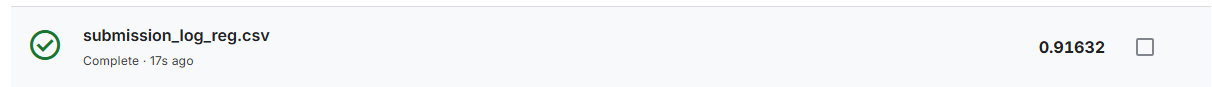

Це не найкращий результат на даний момент. Найкращий був отриманий з логістичної регресії polynominal 4 степеня (результат на лідерборді)

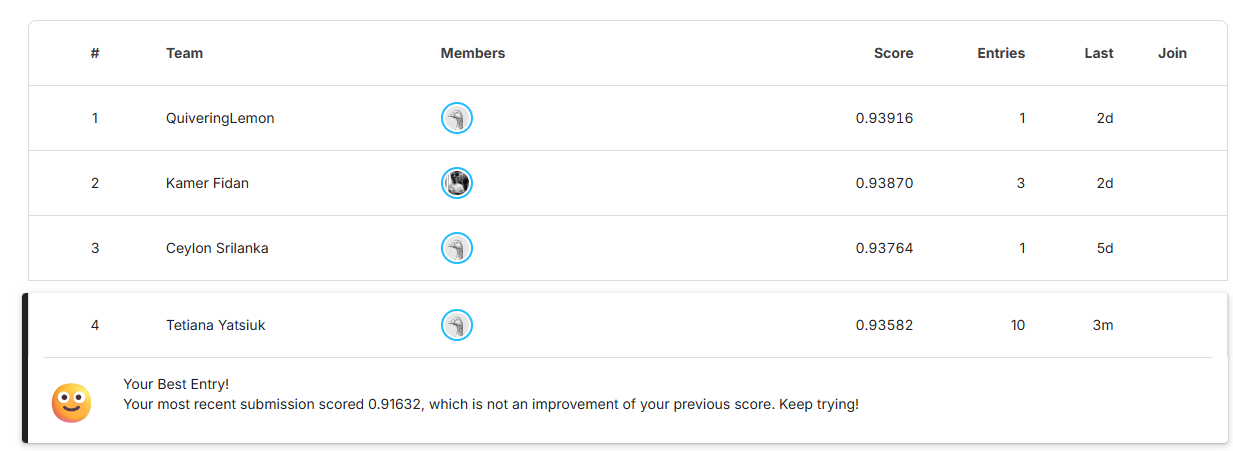